In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd
import pickle
from tqdm import tqdm
import scipy.stats as st
from matplotlib import gridspec

import sys
sys.path.append('../../python/6_CRM')
from CRM import CRM
from CRM_utils import has_converged
from scipy.stats import rankdata


In [4]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '6_CRM'
results_folder = git_folder / 'simulation_results' / 'n_cs_vs_K_parameter_swipe'
figures_folder = git_folder / 'Figures' / '6_CRM'

run = '20251216-120719'
fn_data = f'{run}_data.npz'
# final_abundance_matrix = np.load(results_folder / fn_abundances)['arr_0']

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)


data = np.load(results_folder / fn_data)



In [5]:
all_N_final = data['all_N_final']

In [6]:
richness_matrix = np.sum(data['all_N_final']>1e-6, axis=2)

# Make variable lists from args


In [7]:

n_cs_arr = np.linspace(args.cs_min, args.cs_max, num=args.N_cs, dtype=int, endpoint = True)
K_std_arr = np.linspace(args.K_std_min, args.K_std_max, num = args.N_K_std, endpoint = True)
c_arr = np.linspace(args.csp_min, args.csp_max, num = args.N_Csp, endpoint = True)


# Get conditions

In [8]:
n_cs_arr

array([ 1,  3,  6,  9, 11, 14, 17, 19, 22, 25, 27, 30, 33, 35, 38, 41])

In [9]:
i = 0
stop = False
selected_data = []
i_info = {}
for n_cs in n_cs_arr:
    for K_std in K_std_arr:
        for C_sparsity in c_arr:
            i_info[i] = (n_cs, K_std, C_sparsity)
            if (n_cs >= 10):# and (K_std >= 1):
                for iteri in range(20):
                    # key = (n_cs, K_std, C_sparsity, iteri)
                    C = data[f'C_{i}_{iteri}']
                    D = data[f'D_{i}_{iteri}']
                    K = data[f'K_{i}_{iteri}']
                    selected_data.append({'C': C, 'D': D, 'n_cs': n_cs, 'K_std': K_std, 'C_sparsity': C_sparsity, 'iteri': iteri, 'K':K, 'key': f'{i}_{iteri}'})
                    # if len(selected_data) >= 10000:
                    #     stop = True
                    # if stop:
                    #     break
            i+=1
    #         if stop:
    #             break 
    #     if stop:
    #         break
    # if stop:
    #     break



# New simulations

In [10]:
%load_ext autoreload
%autoreload 2

In [11]:
max_time = 2000
initial_abundance = 1e-3


dt = 0.1
method = 'LSODA'
initial_c_conc = 10
new_data = []
N0 = np.ones(4) * initial_abundance
dilution_rate = 0.1
g = 0.1

for i, sdata in enumerate(tqdm(selected_data)):
    n_cs = sdata['n_cs']
    C = sdata['C']
    D = sdata['D']
    K = sdata['K']
    for j in range(1, 2):
        R0 = np.zeros(n_cs)
        R0[j] = initial_c_conc
        l = args.leakage
        if C[:, j].max()*g < 2*dilution_rate:
            continue
        c = CRM(4, n_cs, C = C, D=D, dilution_rate=0.1, l=l, K=K, atol=1e-9, rtol=1e-9, g=0.1)
        # sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
        try:
            sol = c.run(max_time, N0.copy(), R0.copy(), dt=dt, method=method, max_calls=1e5)
        except (RuntimeError, ValueError):
            print('Error: ', i, j)
            new_data.append({'final_abundance': np.nan, 'final_resources': np.nan, 'resource_no': j, 'key': sdata['key'], 'success': False})
        else:
            if sol.success:
                new_data.append({'final_abundance': c.N[-1, :], 'final_resources': c.R[-1, :],  'resource_no': j, 'key': sdata['key'], 'success': sol.success, 
                                         'converged': has_converged(c.N, 1e-7)})
        
                                     

 94%|█████████▍| 7451/7920 [12:21<01:15,  6.18it/s]capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
 94%|█████████▍| 7453/7920 [12:25<06:18,  1.23it/s]

Error:  7451 1


100%|██████████| 7920/7920 [13:41<00:00,  9.64it/s]


In [12]:
with open(results_folder / f'change_resource_20251218.pkl', 'wb') as f:
    pickle.dump(new_data, f)

In [13]:
new_richness_data = []
old_richness_data = []

new_abundance_data = []
old_abundance_data = []
other_data = []
C_data = []

for dd in new_data:
    if not dd['success']:
        continue
    if not dd['converged']:
        continue
    dd['Richness'] = np.sum(dd['final_abundance']>1e-6)
    dd['Original richness'] = richness_matrix[i, iteri]
    i = int(dd['key'].split('_')[0])
    iteri = int(dd['key'].split('_')[1])
    
    new_richness_data.append(dd['Richness'])
    old_richness_data.append(dd['Original richness'])
    other_data.append([i, iteri, *i_info[i]])

    old_abundance_data.append(all_N_final[i, iteri, :])
    new_abundance_data.append(dd['final_abundance'])
    C = data[f'C_{i}_{iteri}']
    Cvals = list(C[:, 0])+list(C[:, 1])
    C_data.append(Cvals)
    

IndexError: index 7919 is out of bounds for axis 0 with size 528

In [ ]:
len(other_data), len(new_richness_data), len(old_richness_data)

(5729, 5729, 5729)

In [ ]:
C_df = pd.DataFrame(C_data, columns = [f'C_{i+1}{j+1}' for j in range(2) for i in range(4) ])

In [ ]:
meta_df = pd.DataFrame(other_data, columns=['i', 'iteri', 'n_cs', 'K_std', 'C_sparsity'])

In [ ]:
meta_df = pd.merge(meta_df, C_df, left_index=True, right_index=True)

In [ ]:
df_richness = pd.DataFrame({'Original richness': old_richness_data, 'New richness': new_richness_data})

In [ ]:
df_richnessM = pd.merge(df_richness, meta_df, how='inner', left_index=True, right_index=True)

In [ ]:
old_a_df = pd.DataFrame(old_abundance_data)
new_a_df = pd.DataFrame(new_abundance_data)
old_aM_df = pd.merge(old_a_df, meta_df, how='inner', left_index=True, right_index=True)
new_aM_df = pd.merge(new_a_df, meta_df, how='inner', left_index=True, right_index=True)


In [ ]:
old_aM_df.reset_index(inplace=True)
new_aM_df.reset_index(inplace=True)

In [ ]:
old_a = old_aM_df.melt(var_name='Species', value_name='R1 abundance', id_vars=['i', 'iteri', 'n_cs', 'K_std', 'C_sparsity', 'index']+C_df.columns.tolist())
new_a = new_aM_df.melt(var_name='Species', value_name='R2 abundance', id_vars=['i', 'iteri', 'n_cs', 'K_std', 'C_sparsity', 'index']+C_df.columns.tolist())   

In [ ]:
abundance_df = pd.merge(old_a, new_a[['index', 'Species', 'R2 abundance']], on=['index', 'Species'])

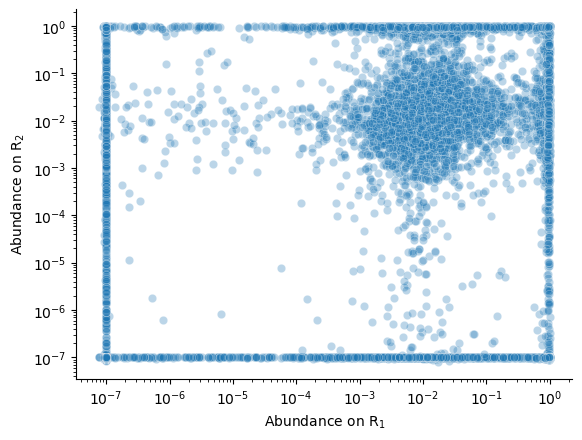

In [ ]:
sns.scatterplot(data=abundance_df, x='R1 abundance', y='R2 abundance', alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Abundance on $\rm{R_1}$')
plt.ylabel(r'Abundance on $\rm{R_2}$')
sns.despine()

In [ ]:
df_richnessM = df_richnessM.loc[df_richnessM['Original richness'].isin([1,2,3,4])]

In [ ]:
for i, row in abundance_df.iterrows():
    abundance_df.at[i, 'C1'] = row[f'C_{row['Species']+1}1']
    abundance_df.at[i, 'C2'] = row[f'C_{row['Species']+1}2']

In [ ]:
abundance_df['R1 rank'] = abundance_df.groupby('index')['R1 abundance'].rank(method='max', ascending=False)

In [ ]:
abundance_df.loc[abundance_df['R1 abundance']<1e-6, 'R1 rank'] = 0

In [ ]:
abundance_df['C1 rank'] = abundance_df.groupby('index')['C1'].rank(method='min', ascending=False)

In [ ]:
nanidx = abundance_df['R1 rank'].isna() 

In [ ]:
st.pearsonr(abundance_df.loc[~nanidx, 'C1 rank'], abundance_df.loc[~nanidx, 'R1 rank'])

ValueError: data type <class 'numpy.object_'> not inexact

In [ ]:
abundance_df.sort_values('index')

,i,iteri,n_cs,K_std,C_sparsity,index,C_11,C_21,C_31,C_41,...,C_32,C_42,Species,R1 abundance,R2 abundance,C1,C2,R1_rank,R1 rank,C1 rank
0,132,0,11,0.1,0.0,0,0.805449,1.840814,2.315581,1.065750,...,3.383266,0.330820,0,9.966435e-08,9.999288e-08,0.805449,2.779591,NaN,0,4.0
11458,132,0,11,0.1,0.0,0,0.805449,1.840814,2.315581,1.065750,...,3.383266,0.330820,2,9.689492e-01,9.807892e-01,2.315581,3.383266,1.0,1.0,1.0
17187,132,0,11,0.1,0.0,0,0.805449,1.840814,2.315581,1.065750,...,3.383266,0.330820,3,9.996599e-08,9.689480e-08,1.065750,0.330820,NaN,0,3.0
5729,132,0,11,0.1,0.0,0,0.805449,1.840814,2.315581,1.065750,...,3.383266,0.330820,1,9.999193e-08,9.996884e-08,1.840814,2.073206,NaN,0,2.0
1,132,1,11,0.1,0.0,1,1.571354,1.896899,1.958414,3.002067,...,0.392772,4.455234,0,9.999941e-08,9.992611e-08,1.571354,1.090724,NaN,0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5727,527,18,41,2.0,0.4,5727,0.547335,0.000000,2.153767,0.000000,...,0.000000,2.379871,0,9.294546e-03,9.998886e-08,0.547335,2.566984,3.0,3.0,2.0
11457,527,19,41,2.0,0.4,5728,0.000000,2.012826,0.000000,0.000000,...,0.000000,0.627489,1,7.187347e-01,6.673401e-01,2.012826,5.156449,1.0,1.0,1.0
5728,527,19,41,2.0,0.4,5728,0.000000,2.012826,0.000000,0.000000,...,0.000000,0.627489,0,1.125775e-02,4.596773e-03,0.000000,0.966539,2.0,2.0,2.0
17186,527,19,41,2.0,0.4,5728,0.000000,2.012826,0.000000,0.000000,...,0.000000,0.627489,2,9.952404e-08,9.907661e-08,0.000000,0.000000,NaN,0,2.0


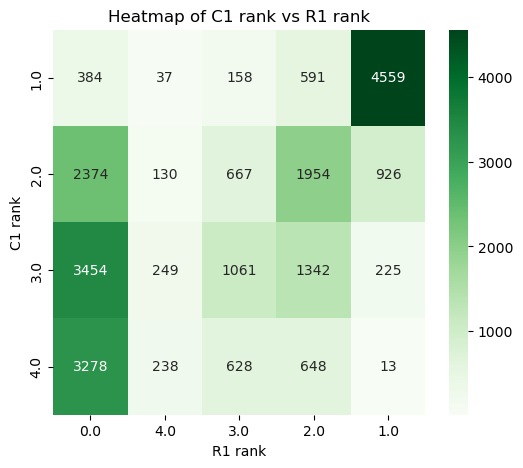

In [ ]:
# Drop NaNs to avoid issues
heatmap_df = abundance_df#.dropna(subset=['C1 rank', 'R1 rank'])

# Create a 2D histogram (pivot table) of counts
pivot = pd.crosstab(heatmap_df['C1 rank'], heatmap_df['R1 rank'])
pivot = pivot.loc[[1,2,3,4], [0,4,3,2,1]]

plt.figure(figsize=(6, 5))
sns.heatmap(pivot, cmap='Greens', annot=True, fmt='d')
plt.xlabel('R1 rank')
plt.ylabel('C1 rank')
plt.title('Heatmap of C1 rank vs R1 rank')
plt.show()

In [ ]:


df_balancedM = df_richnessM.groupby('Original richness', group_keys=False).sample(n=654, random_state=42)
# Create the pivot table
# pivot = pd.crosstab(df_balancedM['Original richness'], df_balancedM['New richness'])
pivot = df_richnessM.pivot_table(index='Original richness', columns='New richness')

pivot = pivot.T
pivot = pivot.loc[[4,3,2,1],[1,2,3,4]]


# Set up the figure with gridspec
fig = plt.figure(figsize=(4, 4))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.15], height_ratios=[0.15, 1],
                       wspace=0.05, hspace=0.05)

# Marginal distributions
ax_marg_y = fig.add_subplot(gs[1, 1], sharey=None)
ax_marg_x = fig.add_subplot(gs[0, 0], sharex=None)
ax_heatmap = fig.add_subplot(gs[1, 0])

# Heatmap in the center
sns.heatmap(pivot, ax=ax_heatmap, cmap='Greens', annot=True, fmt='d',
            cbar=False)
ax_heatmap.set_xlabel(r'Richness on $\rm{R_1}$')
ax_heatmap.set_ylabel(r'Richness on $\rm{R_2}$')

# ax_heatmap.set_yticks([])
# ax_heatmap.set_yticklabels([])
# Marginal barplots
ax_marg_y.barh(pivot.index, pivot.sum(axis=1), color='C2')
ax_marg_x.bar(pivot.columns, pivot.sum(axis=0), color='C2')

# Remove ticks/labels for marginals
sns.despine(ax=ax_marg_y, left=False, bottom=False)
sns.despine(ax=ax_marg_x, left=False, bottom=False)

# ax_marg_y.axis('off')
# ax_marg_x.axis('off')
ax_marg_y.set_yticks([])
ax_marg_x.set_xticks([])
ax_marg_x.set_ylabel('Total')
ax_marg_y.set_xlabel('Total')
plt.savefig(figures_folder / 'change_resource_richness_heatmap.pdf', bbox_inches='tight')
plt.show()

NameError: name 'df_richnessM' is not defined

In [224]:
df_richnessM30 = df_richnessM.loc[(df_richnessM['n_cs'] >= 30)]

df_richnessM30['Original richness'].value_counts()

Original richness
3    839
2    707
1    455
4    399
Name: count, dtype: int64

New richness,1,2,3,4
Original richness,,,,
1,56,87,22,1
2,106,309,214,41
3,47,195,444,148
4,7,41,220,169


1.0685729482335637e-09
[np.float64(0.0009792280258601835), np.float64(6.714991129070215e-05), np.float64(9.920463961758868), np.float64(0.00010007100338958013), np.float64(0.00034399765008768206), np.float64(0.00027501282745836283), np.float64(0.00010794351945686938), np.float64(6.658441552737843e-05), np.float64(0.0007312244945034105), np.float64(0.0005407611359216388), np.float64(0.00010725458083168822), np.float64(0.0013294012816801018), np.float64(0.0012948727386433098), np.float64(0.00026984090582238355), np.float64(4.98223121421424e-05), np.float64(0.00015300595061253962), np.float64(1.7057165390919943e-05), np.float64(6.276017681028816e-05), np.float64(2.5328019080891247e-05), np.float64(7.638281106783572e-05), np.float64(0.0006751831090237984), np.float64(3.0478833607399043), np.float64(0.00010685522450888289), np.float64(9.539906455435046), np.float64(0.00026221076374382466), np.float64(0.00031014989686689), np.float64(0.00015283694031646198), np.float64(0.0001451669442591415)

(array([334.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 474.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 472.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0., 164.]),
 array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2,
        2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5,
        3.6, 3.7, 3.8, 3.9, 4. ]),
 <BarContainer object of 30 artists>)

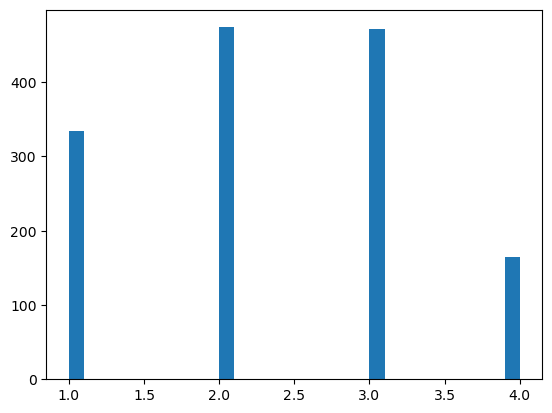

In [305]:
min_values = []
final_resource = []
richness_list = []
for m in monoculture_data:
    if isinstance(m['final_resources'], np.ndarray):
        min_values.append(m['final_resources'].min())
        final_resource.append(m['final_resources'][0])
        richness_list.append(richness_matrix[m['i'], m['j']])
print(np.min(min_values))
print(final_resource)
plt.hist(richness_list, bins=30)

# Spent medium experiment

In [ ]:
spent_monoculture_data = []
spent_inoculation = 1e-6
for mcdata in tqdm(monoculture_data):
    if np.isnan(mcdata['final_abundance']) or mcdata['final_abundance'] == initial_abundance:
        continue
    if mcdata['final_resources'][0]>0.5*initial_c_conc:
        # Discard spent media from communities that did not consume most of the primary resource
        continue
    i = mcdata['i']
    j = mcdata['j']
    k_spent = mcdata['species_no']
    C = data[f'C_{i}{j}']
    D = data[f'D_{i}{j}']
    K = data[f'K_{i}{j}']
    l = args.leakage * np.ones(1)
    R0 = mcdata['final_resources']
    R0[R0<0] = 0
    N0 = np.ones(1) * spent_inoculation
    n_cs = R0.shape[0]
    for k in range(4):
        if k != k_spent:
            c = CRM(1, n_cs, C = C[k, None], D=D[k, None], dilution_rate=1e-3, l=l, K=K[k, None])
            try:
                sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
            except (RuntimeError, ValueError):
                print('Error: ', i, j, k)
                # spent_monoculture_data.append({'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': i, 'j':j})
            else:
                if sol.success:
                    spent_monoculture_data.append({'final_abundance': c.N[-1, :], 'final_resources': c.R[-1, :], 'spent_medium_from': k_spent, 'species_no': k, 'i': i, 'j':j})
        



100%|██████████| 1460/1460 [00:41<00:00, 35.52it/s]


In [ ]:
final_abundance_sm = []
for sm in spent_monoculture_data:
    if not np.isnan(sm['final_abundance'][0]) and (sm['final_abundance'][0]<1e3) and (sm['final_abundance'][0]>0):
        final_abundance_sm.append([sm['final_abundance'][0], sm['i'], sm['j'], sm['species_no'], sm['spent_medium_from'], richness_matrix[sm['i'], sm['j']]]) 

In [ ]:
final_abundance_sm_df = pd.DataFrame(final_abundance_sm, columns=['Final abundance', 'i', 'j', 'species_no', 'spent_medium_from', 'richness'])


In [ ]:
len(final_abundance_sm_df)

4065

In [ ]:
final_abundance_sm_df.max()

Final abundance        4.905961
i                    335.000000
j                     40.000000
species_no             3.000000
spent_medium_from      3.000000
richness               4.000000
dtype: float64

In [ ]:
final_abundance_sm_df['log10_Final_abundance'] = np.log10(final_abundance_sm_df['Final abundance'])

In [ ]:
mean_fa = final_abundance_sm_df.groupby(['i', 'j']).agg({'log10_Final_abundance': ['mean', 'std', 'min'], 'richness':'first'}).reset_index()

In [ ]:
mean_fa.columns = ['i', 'j', 'log10_Final_abundance_mean', 'log10_Final_abundance_std', 'log10_Final_abundance_min', 'richness']

<Axes: xlabel='richness', ylabel='log10_Final_abundance_min'>

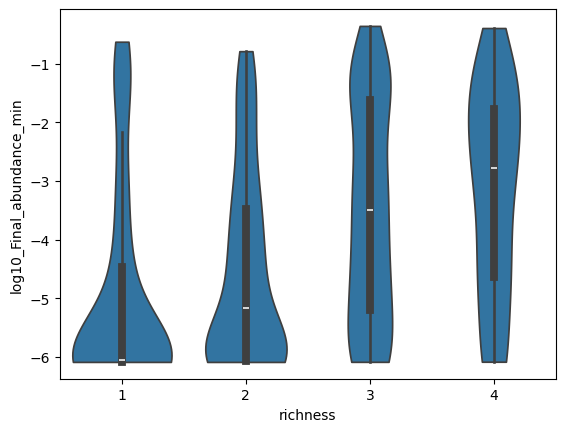

In [ ]:
sns.violinplot(data=mean_fa, x='richness', y='log10_Final_abundance_min', cut=0)
# plt.yscale('log')

In [ ]:
final_abundance_sm_df['log10(Fold change)'] = np.log10(final_abundance_sm_df['Final abundance']/spent_inoculation)

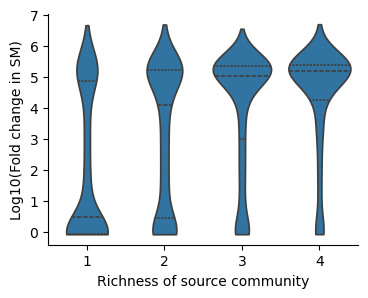

In [362]:
fig, ax = plt.subplots(figsize=(4,3))
sns.violinplot(data=final_abundance_sm_df, x='richness', y='log10(Fold change)', cut=0, ax = ax, inner="quart")
sns.despine()
plt.xlabel('Richness of source community')
plt.ylabel('Log10(Fold change in SM)')
# plt.yscale('log')
plt.savefig(figures_folder/'fold_change_vs_richness_spent.pdf', bbox_inches='tight')

# Interactions

## in fresh medium

In [319]:
paired_fresh_culture_data = []
karr = np.arange(4)
error_count = 0
for sdata in tqdm(selected_data[::20]):
    n_cs = sdata['n_cs']
    R0 = np.zeros(n_cs)
    R0[0] = initial_c_conc
    C = sdata['C']
    D = sdata['D']
    K = sdata['K']
    N0 = np.ones(2) * spent_inoculation
    
    pairs = [(i, j) for i in karr for j in karr if i != j and i != k_spent and j != k_spent]
    i = sdata['i']
    j = sdata['j']
    for pair in pairs:
        if C[pair,0].min()<1e-6:
            continue
        c = CRM(2, n_cs, C = C[pair, :], D=D[pair, :], dilution_rate=1e-3, l=l, K=K[pair, :])
        try:
            sol = c.run(max_time, N0.copy(), R0.copy(), dt=dt, method=method, max_calls=1e5)
        except (RuntimeError, ValueError):
            # print('Error: ', i, j, k)
            error_count += 1

            # spent_monoculture_data.append({'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': i, 'j':j})
        else:
            if sol.success:
                paired_fresh_culture_data.append({'final_abundance': c.N[-1, :], 'pair': pair, 'i': i, 'j':j})
        


100%|██████████| 454/454 [01:59<00:00,  3.78it/s]


# in spent medium

In [ ]:
paired_culture_data = []
karr = np.arange(4)
error_count = 0
for mcdata in tqdm(monoculture_data):
    if np.isnan(mcdata['final_abundance']) or mcdata['final_abundance'] == initial_abundance:
        continue
    if mcdata['final_resources'][0]>0.5*initial_c_conc:
        # Discard spent media from communities that did not consume most of the primary resource
        continue
    i = mcdata['i']
    j = mcdata['j']
    k_spent = mcdata['species_no']
    C = data[f'C_{i}{j}']
    D = data[f'D_{i}{j}']
    K = data[f'K_{i}{j}']
    l = args.leakage * np.ones(2)
    R0 = mcdata['final_resources']
    R0[R0<0] = 0
    N0 = np.ones(2) * spent_inoculation
    n_cs = R0.shape[0]

    pairs = [(i, j) for i in karr for j in karr if i != j and i != k_spent and j != k_spent]
    for pair in pairs:
        c = CRM(2, n_cs, C = C[pair, :], D=D[pair, :], dilution_rate=1e-3, l=l, K=K[pair, :])
        try:
            sol = c.run(max_time, N0.copy(), R0.copy(), dt=dt, method=method, max_calls=1e5)
        except (RuntimeError, ValueError):
            # print('Error: ', i, j, k)
            error_count += 1

            # spent_monoculture_data.append({'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': i, 'j':j})
        else:
            if sol.success:
                paired_culture_data.append({'final_abundance': c.N[-1, :], 'spent_medium_from': k_spent, 'pair': pair, 'i': i, 'j':j})
        



100%|██████████| 1460/1460 [01:54<00:00, 12.77it/s]


## Calculate interactions

# fresh

In [320]:
monoculture_df = pd.DataFrame(monoculture_data)
monoculture_df.drop(columns=['final_resources'], inplace=True)
monoculture_df.final_abundance = monoculture_df.final_abundance.astype(float)

In [321]:
parsed_fresh_pair = []
for pfc in paired_fresh_culture_data:
    p1, p2 = pfc['pair']
    parsed_fresh_pair.append([int(p1), pfc['final_abundance'][0], int(p2), pfc['final_abundance'][1], int(pfc['i']), int(pfc['j']), richness_matrix[int(pfc['i']), int(pfc['j'])]])
    parsed_fresh_pair.append([int(p2), pfc['final_abundance'][1], int(p1), pfc['final_abundance'][0], int(pfc['i']), int(pfc['j']), richness_matrix[int(pfc['i']), int(pfc['j'])]])
fresh_pair_df = pd.DataFrame(parsed_fresh_pair, columns=['species_no', 'final_abundance', 'co_species_no', 'co_final_abundance', 'i', 'j', 'richness'])

In [322]:
fresh_interaction_df = pd.merge(fresh_pair_df, monoculture_df, left_on=['species_no', 'i', 'j'], right_on=['species_no', 'i', 'j'], suffixes=('_pair', '_mono'))

In [323]:
fresh_interaction_df['interaction'] = np.log10(fresh_interaction_df['final_abundance_pair']/fresh_interaction_df['final_abundance_mono'])

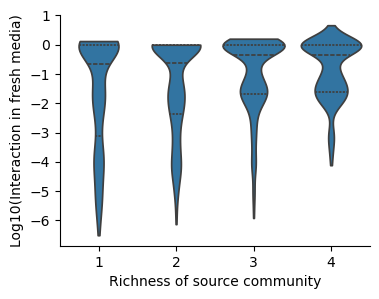

In [360]:
fig, ax = plt.subplots(figsize=(4,3))
sns.violinplot(data=fresh_interaction_df, x='richness', y='interaction', cut=0, inner="quart", ax = ax)
sns.despine()
plt.xlabel('Richness of source community')
plt.ylabel('Log10(Interaction in fresh media)')
# plt.axhline(0, color='k', ls='--')
plt.savefig(figures_folder/'interaction_vs_richness_fresh.pdf', bbox_inches='tight')

# Spent

In [ ]:
spent_monoculture_df = pd.DataFrame(spent_monoculture_data)
spent_monoculture_df.drop(columns=['final_resources'], inplace=True)
spent_monoculture_df.final_abundance = spent_monoculture_df.final_abundance.astype(float)

In [ ]:
parsed_paired = []
for entry in paired_culture_data:
    fa1 = entry['final_abundance'][0]
    fa2 = entry['final_abundance'][1]
    if not np.isnan(fa1) and not np.isnan(fa2):
        p1, p2 = entry['pair']
        richness = richness_matrix[entry['i'], entry['j']]
        parsed_paired.append([p1, fa1, p2, fa2, entry['i'], entry['j'], entry['spent_medium_from'], richness])
        parsed_paired.append([p2, fa2, p1, fa1, entry['i'], entry['j'], entry['spent_medium_from'], richness])
spent_paired_df = pd.DataFrame(parsed_paired, columns=['species_no', 'final_abundance', 'co_species_no', 'co_final_abundance', 'i', 'j', 'spent_medium_from', 'richness'])

In [ ]:
interaction_df = pd.merge(spent_paired_df, spent_monoculture_df, right_on=['i', 'j', 'spent_medium_from', 'species_no'], left_on=['i', 'j', 'spent_medium_from', 'species_no'], suffixes=('_pair', '_single'))

In [ ]:
monoculture_df = pd.DataFrame(monoculture_data)
monoculture_df.dropna(inplace=True)
monoculture_df.drop(columns=['final_resources', 'success', 'converged'], inplace=True)

monoculture_df.final_abundance = monoculture_df.final_abundance.astype(float)

In [ ]:
monoculture_df

,final_abundance,species_no,i,j,success,converged
0,9.758934,2,17,10,True,True
1,9.613620,3,17,10,True,True
2,0.082861,1,17,30,True,False
3,9.373021,2,17,30,True,True
4,9.330597,3,17,30,True,True
...,...,...,...,...,...,...
1453,9.670241,3,334,40,True,True
1454,9.415096,0,335,10,True,True
1457,9.416521,0,335,30,True,True
1458,9.478738,1,335,30,True,True


In [ ]:
final_abundance_sm_df

,Final abundance,i,j,species_no,spent_medium_from,richness,log10_Final_abundance,log10(Fold change)
0,0.000260,17,10,0,2,1,-3.585372,2.414628
1,0.159014,17,10,1,2,1,-0.798566,5.201434
2,0.119099,17,10,3,2,1,-0.924092,5.075908
3,0.003150,17,10,0,3,1,-2.501698,3.498302
4,0.130070,17,10,1,3,1,-0.885822,5.114178
...,...,...,...,...,...,...,...,...
4060,0.157811,335,30,2,1,3,-0.801864,5.198136
4061,0.109855,335,30,3,1,3,-0.959180,5.040820
4062,0.108302,335,30,0,2,3,-0.965363,5.034637
4063,0.036071,335,30,1,2,3,-1.442838,4.557162


In [ ]:
interaction_df['interaction'] = np.log10(interaction_df['final_abundance_pair']/interaction_df['final_abundance_single'])


In [345]:
for i, row in interaction_df.iterrows():
    ii = int(row['i'])
    jj = int(row['j'])
    sn = int(row['species_no'])
    csn = int(row['co_species_no'])
    source_n = int(row['spent_medium_from'])
    interaction_df.at[i, '4-culture_final_abundance'] = all_N_final[ii,jj,sn]
    # interaction_df.at[i, '4-culture_final_abundance_co'] = all_N_final[ii,jj,csn]
    interaction_df.at[i, '4-culture_final_abundance_source'] = all_N_final[ii,jj,source_n]
    four_species_abundance = all_N_final[ii,jj]
    four_species_abundance_ranked = rankdata(four_species_abundance)
    interaction_df.at[i, '4-culture_final_abundance_rank'] = four_species_abundance_ranked[sn]
    # interaction_df.at[i, '4-culture_final_abundance_co_rank'] = four_species_abundance_ranked[csn]
    interaction_df.at[i, '4-culture_final_abundance_source_rank'] = four_species_abundance_ranked[source_n]
    


In [346]:
full_df = pd.merge(interaction_df, monoculture_df, right_on=['i', 'j', 'species_no'], left_on=['i', 'j', 'species_no'], suffixes=('', '_fresh'))
full_df['final_abundance_fresh'] = full_df['final_abundance']

In [347]:
full_Idf = pd.merge(full_df, fresh_interaction_df, left_on=['i', 'j', 'species_no', 'co_species_no', 'richness'], right_on=['i', 'j', 'species_no', 'co_species_no', 'richness'], suffixes=('_spent', '_fresh'))

In [ ]:
# idx = (interaction_df['4-culture_final_abundance_source_rank'] <= interaction_df['richness'])#&(full_df['final_abundance_single']>1e-2)
full_Idf['Survived in 4-culture'] = full_Idf['4-culture_final_abundance']>1e-6

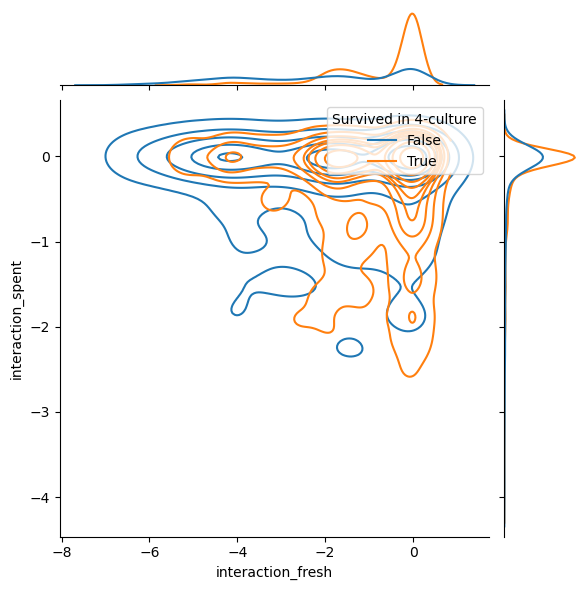

In [350]:
sns.jointplot(data=full_Idf.loc[idx], x='interaction_fresh', y='interaction_spent', hue='Survived in 4-culture', palette='tab10', kind='kde')

In [ ]:
idx = interaction_df['4-culture_final_abundance_source_rank'] >= interaction_df['richness']

(array([3584.,  332.,  272.,  184.,  192.,  176.,  220.,  216.,  232.,
         176.,  176.,  220.,  216.,  180.,  208.,  244.,  224.,  188.,
         260.,  336.,  472.,  744., 1412., 2416., 2424.,  740.,   28.,
          12.,   12.,  164.]),
 array([-6.08566019, -5.85978071, -5.63390123, -5.40802176, -5.18214228,
        -4.9562628 , -4.73038333, -4.50450385, -4.27862437, -4.05274489,
        -3.82686542, -3.60098594, -3.37510646, -3.14922699, -2.92334751,
        -2.69746803, -2.47158856, -2.24570908, -2.0198296 , -1.79395013,
        -1.56807065, -1.34219117, -1.11631169, -0.89043222, -0.66455274,
        -0.43867326, -0.21279379,  0.01308569,  0.23896517,  0.46484464,
         0.69072412]),
 <BarContainer object of 30 artists>)

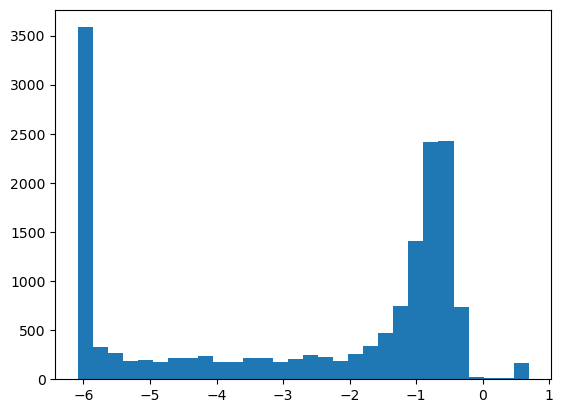

In [ ]:
plt.hist(np.log10(full_df.final_abundance_sm), bins =30)

8304


<Axes: xlabel='richness', ylabel='interaction'>

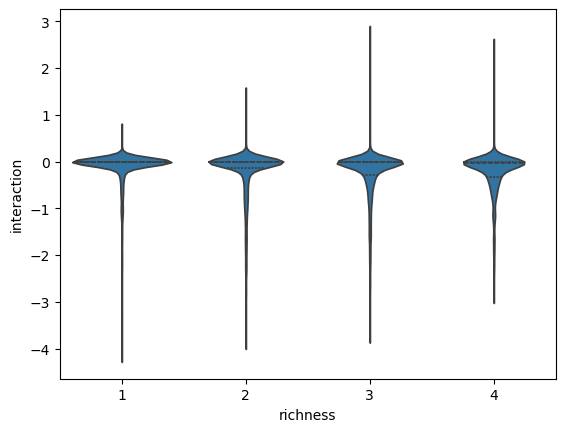

In [ ]:
idx = (interaction_df['4-culture_final_abundance_source_rank'] <= interaction_df['richness'])#&(full_df['final_abundance_single']>1e-2)
print(idx.sum())
sns.violinplot(data=interaction_df, x='richness', y='interaction', cut=0, inner="quart")
# plt.ylim(-2, 2)
# plt.axhline(0, color='k', ls='--')

In [ ]:
full_df.loc[idx].head(10)

,species_no,final_abundance_pair,co_species_no,co_final_abundance,i,j,spent_medium_from,richness,final_abundance_single,interaction,4-culture_final_abundance_source,4-culture_final_abundance_source_rank,final_abundance,final_abundance_fresh
0,3,0.119074,0,0.000142,17,10,2,1,0.119099,-0.000091,9.822912e+00,4.0,9.613620,9.613620
1,3,0.097647,1,0.145251,17,10,2,1,0.119099,-0.086250,9.822912e+00,4.0,9.613620,9.613620
2,3,0.119074,0,0.000142,17,10,2,1,0.119099,-0.000091,9.822912e+00,4.0,9.613620,9.613620
3,3,0.097647,1,0.145251,17,10,2,1,0.119099,-0.086250,9.822912e+00,4.0,9.613620,9.613620
4,2,0.010184,0,0.003030,17,10,3,1,0.010358,-0.007389,9.819384e-08,3.0,9.758934,9.758934
5,2,0.001776,1,0.130047,17,10,3,1,0.010358,-0.765880,9.819384e-08,3.0,9.758934,9.758934
6,2,0.010184,0,0.003030,17,10,3,1,0.010358,-0.007389,9.819384e-08,3.0,9.758934,9.758934
7,2,0.001776,1,0.130047,17,10,3,1,0.010358,-0.765880,9.819384e-08,3.0,9.758934,9.758934
8,1,0.000450,0,0.372463,17,30,2,1,0.197674,-2.642498,9.996946e-08,2.0,0.082861,0.082861
9,3,0.001999,0,0.372671,17,30,2,1,0.069145,-1.538852,9.996946e-08,2.0,9.330597,9.330597


<Axes: xlabel='richness', ylabel='interaction'>

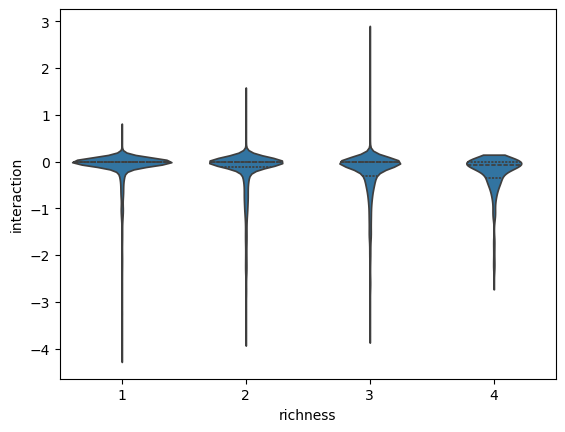

In [ ]:
# idx = interaction_df['4-culture_final_abundance_source'] > 1
sns.violinplot(data=interaction_df.loc[idx], x='richness', y='interaction', cut=0, inner="quart")

In [ ]:
pairs = [(i, j) for i in karr for j in karr if i != j and i != 0 and j != 0]


In [ ]:
C[pairs[1],None].shape

(2, 1, 41)

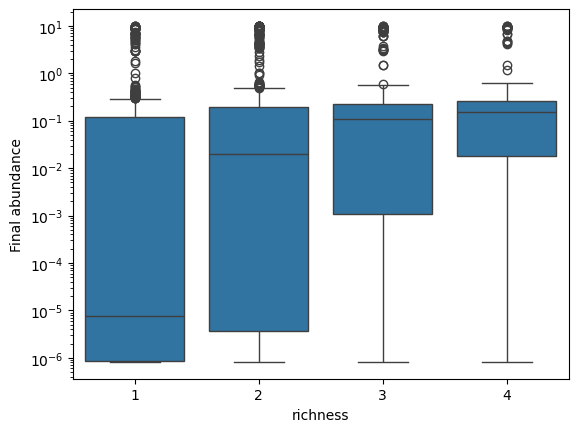

In [ ]:
sns.boxplot(data=final_abundance_sm_df, x='richness', y='Final abundance')
plt.yscale('log')

In [ ]:
max_time = 200
initial_abundance = 1e-2


dt = 1
method = 'LSODA'
initial_c_conc = 10
monoculture_data2 = []
N0 = np.ones(1) * initial_abundance
R_min_values = []
for i, sdata in enumerate(tqdm(selected_data[::5])):
    n_cs = sdata['n_cs']
    R0 = np.zeros(n_cs)
    R0[0] = initial_c_conc
    C = sdata['C']
    D = sdata['D']
    K = sdata['K']
    # K = np.ones_like(C)
    # D = np.ones_like(D)/(n_cs-1)
    # D = D/np.sum(D, axis=1, keepdims=True)
    

    if n_cs == 1:
        l = 0
    else:
        l = args.leakage
    l = l*np.ones(1)
    for k in range(4):
        if C[k,0]<1e-6:
            continue
        # c = CRM(1, n_cs, C = C[k, None], D=D[k, None], dilution_rate=0, l=l,  K=K[k, None])
        # sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
        try:
            # sol = c.run(max_time, N0.copy(), R0.copy(), dt=dt, method=method, max_calls=1e5)
            # muMatrix,kMatrix,dTensor,lVector,delta,Ns,Nr,N0,R0,t_max):
            sol, success = run_lsoda_crossfeeding(C[k, None], K[k, None], D[k, None], l, 0, 1, n_cs, N0, R0, max_time)
        except (RuntimeError, ValueError):
            print('Error: ', i, k)
            monoculture_data2.append({'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': sdata['i'], 'j':sdata['j']})
        else:
            N = sol[:, :1]
            R = sol[:, 1:]
            monoculture_data2.append({'final_abundance': N[-1, :], 'final_resources': R[-1, :], 'species_no': k, 'i': sdata['i'], 'j':sdata['j']})
            R_min_values.append(np.min(R[-1]))
    break                  

  0%|          | 0/1816 [00:01<?, ?it/s]


In [ ]:
monoculture_data

[{'final_abundance': array([9.7601302]),
  'final_resources': array([ 6.47853343e-09,  5.86142978e-09,  7.42788494e-02,  1.46681946e-09,
          6.55376586e-10, -4.53744184e-08,  1.24828083e-02,  5.91792626e-08,
          8.14574590e-07,  6.70526974e-10,  9.05717199e-10,  7.21018565e-02,
          2.08812374e-09,  5.28772994e-10,  7.42264122e-10,  3.20486676e-07,
          2.38023882e-08,  2.41206004e-09,  7.20262084e-10,  5.45566810e-08,
          4.92141579e-02,  4.17908732e-02,  7.77314108e-10]),
  'species_no': 2,
  'i': 17,
  'j': 10},
 {'final_abundance': array([9.61406403]),
  'final_resources': array([-1.71974642e-07,  3.09751372e-07, -1.78861757e-07, -5.13658766e-07,
          2.57731052e-01,  2.63844529e-07,  8.28207149e-07, -2.66363273e-07,
          2.57129005e-02,  1.40909516e-02, -5.72417219e-07,  2.45890412e-02,
          1.46311895e-07,  4.58636322e-03,  3.06764633e-07,  1.56849851e-07,
         -3.74937179e-07, -2.12766059e-06, -1.69192685e-04,  1.28845996e-02,
     

In [ ]:
monoculture_data2

[{'final_abundance': array([9.76013091]),
  'final_resources': array([ 1.31179076e-09,  2.93710950e-09,  7.42788503e-02,  1.10372399e-09,
          7.68493036e-10, -2.92035201e-09,  1.24828104e-02, -8.90452731e-10,
          3.89776733e-07,  4.13040042e-10,  2.76988440e-11,  7.21018621e-02,
         -3.75108558e-10, -7.64371891e-10, -5.27348102e-10,  1.53982852e-07,
         -1.78666987e-09,  1.27865996e-09,  1.20553834e-09, -1.07193367e-08,
          4.92141600e-02,  4.17908751e-02,  6.73305843e-10]),
  'species_no': 2,
  'i': 17,
  'j': 10},
 {'final_abundance': array([9.61390081]),
  'final_resources': array([-9.21904775e-10, -1.02814275e-09, -1.93123547e-10,  2.20239215e-10,
          2.57729263e-01,  4.92074139e-10,  1.51316342e-10, -4.27530543e-09,
          2.57118524e-02,  1.40903324e-02, -7.32668902e-09,  2.45885446e-02,
         -7.56588920e-09,  4.58415921e-03,  2.28662015e-10,  7.49057081e-10,
         -9.04654940e-10,  1.86026044e-10,  1.18030389e-10,  1.28842635e-02,
    

In [ ]:
monoculture_data2

[{'final_abundance': array([9.76013088]),
  'final_resources': array([ 2.17971543e-03,  1.22124176e-04,  2.50165256e-04,  4.79212710e-05,
          4.46673064e-05,  5.51801091e-05, -1.24334745e-03,  4.78075377e-05,
          6.79918201e-05,  4.33568966e-05,  2.98306628e-05, -2.18546556e-03,
          7.43141282e-05,  1.11403824e-04,  1.05092069e-04, -8.93880212e-03,
          4.58100305e-05,  1.51604965e-05,  3.79020117e-05,  1.02339408e-04,
          2.47834499e-02,  6.16599167e-05, -3.71041438e-03,  1.16193909e-04,
         -3.84498736e-07,  6.29365174e-05,  2.18251321e-05,  1.46760467e-05,
          6.12373822e-05]),
  'species_no': 2,
  'i': 17,
  'j': 10},
 {'final_abundance': array([9.61390079]),
  'final_resources': array([ 2.17971543e-03,  1.22124176e-04,  2.50165256e-04,  4.79212710e-05,
          4.46673064e-05,  5.51801091e-05, -1.24334745e-03,  4.78075377e-05,
          6.79918201e-05,  4.33568966e-05,  2.98306628e-05, -2.18546556e-03,
          7.43141282e-05,  1.11403824e

In [ ]:
max_time = 1000
initial_abundance = 1e-2


dt = 0.1
n_transfers = 1
method = 'LSODA'
initial_c_conc = 10
monoculture_data = []
N_data_points = len(n_cs_arr) * len(K_std_arr) * len(c_arr)
for i in tqdm(range(N_data_points)):
    for j in range(args.iterations):
        n_cs = data[f'C_{i}{j}'].shape[1]
        for k in range(4):
            # print(i,j,k)
            R0 = np.zeros(n_cs)
            R0[0] = initial_c_conc
            N0 = np.ones(1) * initial_abundance
            C = data[f'C_{i}{j}']
            D = data[f'D_{i}{j}']
            K = data[f'K_{i}{j}']
            if n_cs == 1:
                l = 0
            else:
                l = args.leakage
            # print(C[k, None].shape)
            c = CRM(1, n_cs, C = C[k, None], D=D[k, None], dilution_rate=0, l=l, K=K[k, None])
            try:
                sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e6)
            except (RuntimeError, ValueError):
                print('Error: ', i, j, k)
                monoculture_data.append({'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': i, 'j':j})
            else:
                monoculture_data.append({'final_abundance': c.N[-1, :], 'final_resources': c.R[-1, :], 'species_no': k, 'i': i, 'j':j})
        

                                     

  1%|          | 4/336 [00:24<33:05,  5.98s/it]

Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Error:  4 23 3
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Error:  4 24 3
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.
Required step size is less than spacing between numbers.


  1%|          | 4/336 [01:56<2:41:43, 29.23s/it]


KeyboardInterrupt: 

1


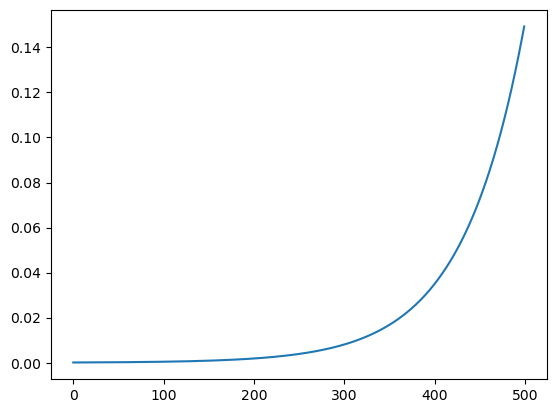

In [ ]:
i = 200
j = 0
k +=1
k = k%3
initial_c_conc = 10
n_cs = data[f'C_{i}{j}'].shape[1]
R0 = np.zeros(n_cs)
R0[0] = initial_c_conc
N0 = np.ones(1) * initial_abundance

max_time = 1000

C = data[f'C_{i}{j}']
D = data[f'D_{i}{j}']
K = data[f'K_{i}{j}']
l = 0
# print(C[k, None].shape)
c = CRM(1, n_cs, C = C[k, None], D=D[k, None], dilution_rate=0, l=l, K=K[k, None])

sol = c.run(500, N0, R0, dt=1, method='BDF', max_calls=1e6)
print(k)
plt.plot(c.N)

In [ ]:
data['C_1710']

array([[0.        , 0.61485534, 0.0530219 , 0.5449299 , 0.02061077,
        0.38230597, 0.21233154, 0.31864192, 0.        , 0.        ,
        0.07605937, 0.        , 0.13757232, 0.63211448, 0.9365973 ,
        0.40290453, 0.70829753, 0.        , 0.06701984, 0.28108151,
        0.        , 0.16140315, 0.13189067],
       [0.        , 0.        , 0.03816445, 0.40147286, 0.        ,
        0.        , 0.        , 0.19638398, 0.23661128, 0.19261202,
        0.        , 0.37825213, 0.01459308, 0.28712264, 0.        ,
        0.18867176, 0.22312356, 0.28992642, 0.        , 0.1380597 ,
        0.        , 0.7280442 , 0.26528301],
       [0.04308098, 0.04375755, 0.        , 0.08256568, 0.0662772 ,
        0.14431795, 0.        , 0.35569259, 0.01570033, 0.23923699,
        0.10269456, 0.        , 0.22768439, 0.15359591, 0.13182147,
        0.01657729, 0.15704975, 0.06628339, 0.13007672, 0.32929292,
        0.        , 0.        , 0.08371643],
       [0.55811795, 0.13433456, 0.10895996, 0.179

In [ ]:
monoculture_data[-1]

{'final_abundance': array([9.99757565]),
 'final_resources': array([ 2.17971543e-03,  1.22124176e-04,  2.50165256e-04,  4.79212710e-05,
         4.46673064e-05,  5.51801091e-05, -1.24334745e-03,  4.78075377e-05,
         6.79918201e-05,  4.33568966e-05,  2.98306628e-05, -2.18546556e-03,
         7.43141282e-05,  1.11403824e-04,  1.05092069e-04, -8.93880212e-03,
         4.58100305e-05,  1.51604965e-05,  3.79020117e-05,  1.02339408e-04,
         2.47834499e-02,  6.16599167e-05, -3.71041438e-03,  1.16193909e-04,
        -3.84498736e-07,  6.29365174e-05,  2.18251321e-05,  1.46760467e-05,
         6.12373822e-05]),
 'species_no': 3,
 'i': 22,
 'j': 20}

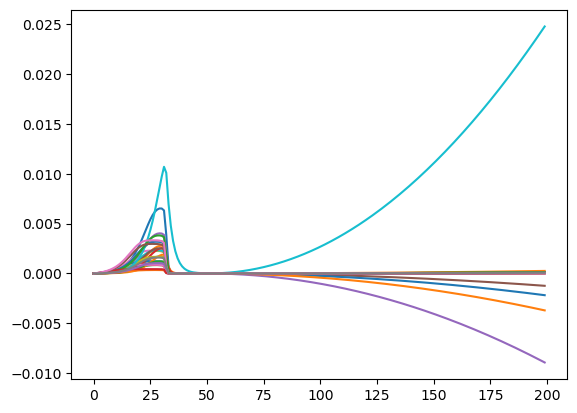

In [ ]:
plt.plot(c.R[:, 1:])

In [ ]:
c = CRM(1, n_cs, C = C[k, None], D=D[k, None], dilution_rate=0, l=l, K=K[k, None])
sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e4)


In [ ]:
c = CRM(1, n_cs, C = C[k, None], D=D[k, None], dilution_rate=0, l=l, K=K[k, None])
c.l

array([0.])